Image manipulation with NumPy - Sargis Gevorgyan

In [816]:
import numpy as np
from PIL import Image

ImageProcessor

In [817]:
class ImageProcessor:
    def __init__(self, path):
        try:
            self.__im_arr = np.array(Image.open(path))
        except FileNotFoundError:
            print('Path have not been found.')

    def get_arr(self):
        return self.__im_arr

    def set_arr(self, arr):
        self.__im_arr = arr

    def depic_old(self):
        print('Before:')
        display(Image.fromarray(self.__im_arr).resize((300, 300)))

    def invert(self):
        fin_arr = self.__im_arr.copy()
        fin_arr[:,:,:3] = 255 - self.__im_arr[:,:,:3]
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))

    def grayscale(self):
        fin_arr = self.__im_arr.copy()
        gray = ((self.__im_arr[:,:,:3].sum(axis=2)) // 3)
        fin_arr[:, :, :3] = gray[:, :, np.newaxis]
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))

    def rotate(self):
        fin_arr = np.transpose(self.__im_arr, (1, 0, 2))
        fin_arr = fin_arr[:,::-1,:]
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))

    def mirror(self):
        fin_arr = self.__im_arr[:,::-1,:]
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))

    def set_transparency(self, val):
        fin_arr = self.__im_arr.copy()
        val = float(val)
        fin_arr[:,:,3] = np.clip(self.__im_arr[:,:,3] * val, 0, 255)
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))

    def set_brightness(self, val):
        fin_arr = self.__im_arr.copy()
        val = float(val)
        fin_arr[:,:,:3] = np.clip(self.__im_arr[:, :, :3] * val, 0, 255)
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))

    def add_border(self):
        h, w = self.__im_arr.shape[:2]
        fin_arr = np.zeros((h + 2*10, w + 2*10, 4), dtype=self.__im_arr.dtype)
        fin_arr[:, :, 3] = 255
        fin_arr[10:10+h, 10:10+w] = self.__im_arr
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))

    def back_to_green(self):
        fin_arr = self.__im_arr.copy()
        mask = fin_arr[:, :, 3] == 0
        fin_arr[mask] = [0, 255, 0, 255]
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))

    def blue_yellow(self):
        fin_arr = self.__im_arr.copy()
        blue_mask = (fin_arr[:,:,2] > fin_arr[:,:,0] + 30) & (fin_arr[:,:,2] > fin_arr[:,:,1] + 30)
        yellow_mask = (fin_arr[:,:,0] > fin_arr[:,:,2] + 30) & (fin_arr[:,:,1] > fin_arr[:,:,2] + 30)
        fin_arr[blue_mask, :3] = self.__im_arr[yellow_mask, :3].mean(axis=0)
        fin_arr[yellow_mask, :3] = self.__im_arr[blue_mask, :3].mean(axis=0)
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))

    def sepia(self):
        fin_arr = self.__im_arr.copy()
        r, g, b = self.__im_arr[:,:,0], self.__im_arr[:,:,1], self.__im_arr[:,:,2]
        fin_arr[:,:,0] = 0.393*r + 0.769*g + 0.189*b
        fin_arr[:,:,1] = 0.349*r + 0.686*g + 0.168*b
        fin_arr[:,:,2] = 0.272*r + 0.534*g + 0.131*b
        self.depic_old()
        print('After:')
        self.set_arr(fin_arr)
        return Image.fromarray(fin_arr).resize((300, 300))


For the first method I used slicing. Through :, :, we take all rows and columns, kind of all pixels, and then :3 to get R, G, B channels we do not need alpha channel which stands for transparency and replaced them with (255 - channel) after that program saves the new logo through setter.

Before:


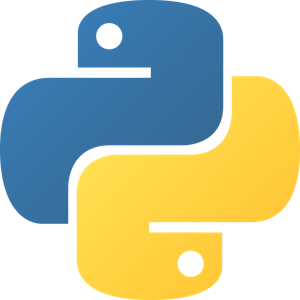

After:


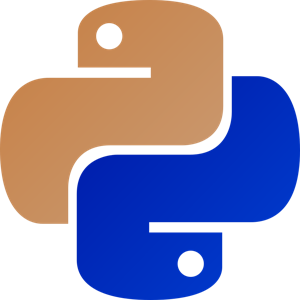

In [818]:
im = ImageProcessor('Python-logo.png')
im.invert()

There was supposed to be grayscale method, but I wanted to show blue_yellow before making logo grayscaled. So initially I wanted to somehow transfer pixels from bluish regions to yellowish and vice verca but I couldn't do it because the sizes of yellow mask and blue mask are not the same. Then I noticed that there are 2 colors only so I could take one transfer to another one but turns out that corners are not clear so transfer was impossible. So I just put mean color to at least get some exchange. For mask I randomly chose this way of checking so that when B is high and R, G low => Bluish set True then use it as mask, when G and R are high and B low => yellow use same method as for B and save.

Before:


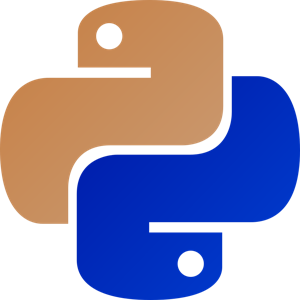

After:


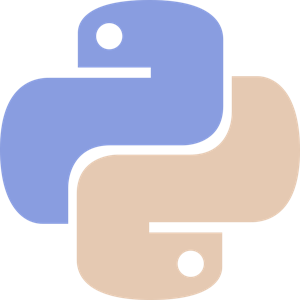

In [819]:
im.blue_yellow()

For each pixel we sum the R, G, and B channels through axis = 2 and divide by 3 to get the average. Then assign this value back to all three channels - when R, G, and B are equal, the pixel appears gray. Important to write np.newaxis (adds axis with size 1) so numpy can broadcast our color to all needed channels. The alpha channel is left unchanged.

Before:


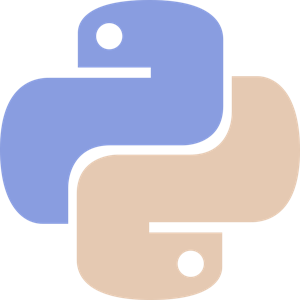

After:


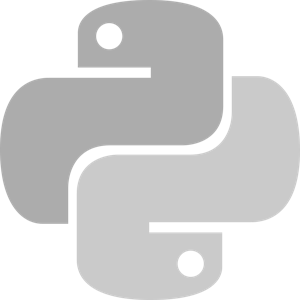

In [820]:
im.grayscale()

First transpose using (1, 0, 2) to swap rows and columns and leave channels untouched. This way we get 90 degree rotation but in counter clock-wise. So it is left to flip along y-axis (2nd dimension used ::-1) or flip columns to get clock-wise.

Before:


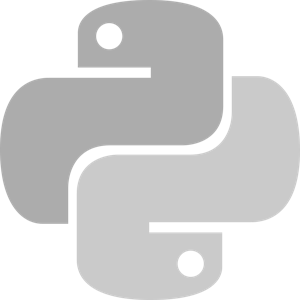

After:


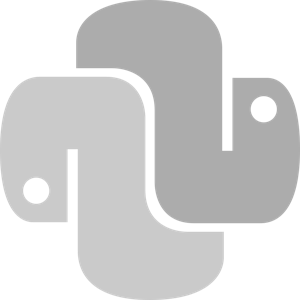

In [821]:
im.rotate()

We already used mirror, simply flip along y-axis which is 2nd dimension (columns)

Before:


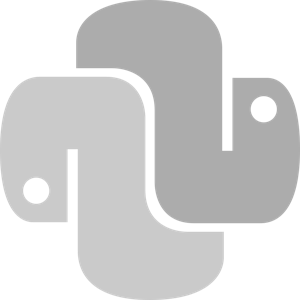

After:


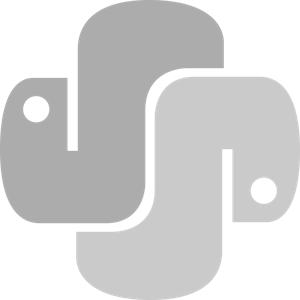

In [822]:
im.mirror()

For transparency I wanter to set some restrictions since it was acting strange for large numbers (I believe it is because of overflow). However, I found a solution (np.clip) which does not let it overflow. It gets more transparent when the number closer to 0 and less transparent when closer to 1. Simply multiply the 3rd element of channels which is an alpha channel by given value and get the result. 0.5 == 50% of initial transparency. For too big numbers it will set 255 for too low 0. Also I don't know why but clip does not normally work with integers so I casted val to float as in the method below.

Before:


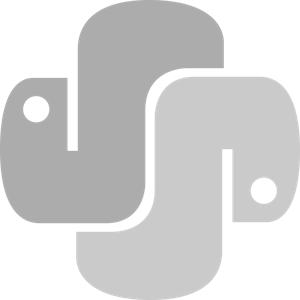

After:


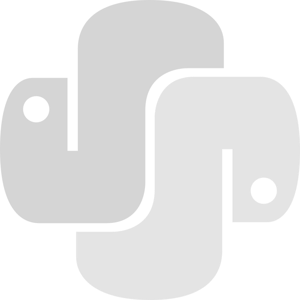

In [823]:
im.set_transparency(0.5)

set_brightness was producing strange results when inputing integers so I casted int val to float val and it worked just fine. Use same clip. Ps val = 1.5 => 50% increase in brightness

Before:


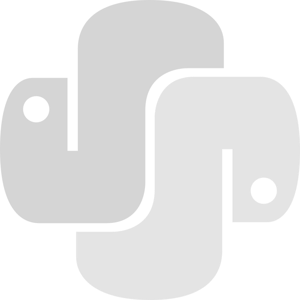

After:


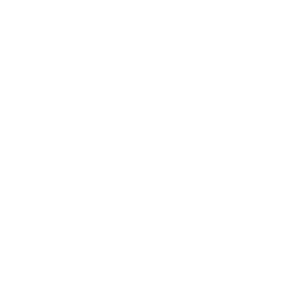

In [824]:
im.set_brightness(1.5)

We create a new array filled with zeros 20 pixels larger in both dimensions. We set the alpha channel to 255 so it is not transparent. Since RGB is 0, it becomes black. Then paste the original image in the center by identation it by 10 pixels from each edge.

Before:


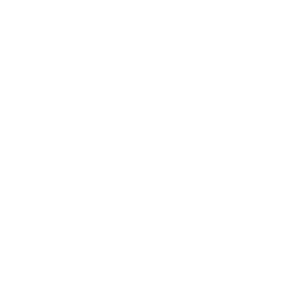

After:


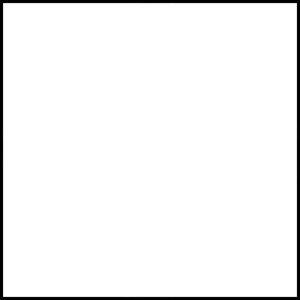

In [825]:
im.add_border()

We create a boolean mask where if alpha equals 0 get True. Then we fill those pixels with green (R=0, G=255, B=0) and set alpha to 255 to make them not transparent. Other pixels unchanged. Interesting fact: when I make background green in pycharm it makes the rest grayish. But it works fine in colab & when I download it, it is formatted normally. Maybe some bug in pycharm render.

Before:


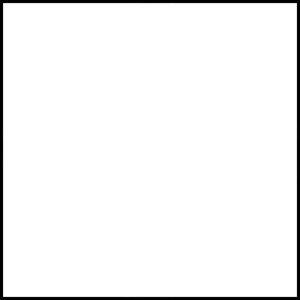

After:


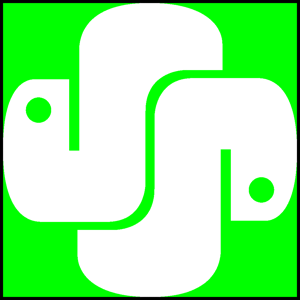

In [826]:
im.back_to_green()

Just extract R, G, B use given formulas and set them for appropriate channels.

Before:


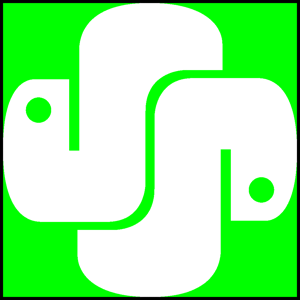

After:


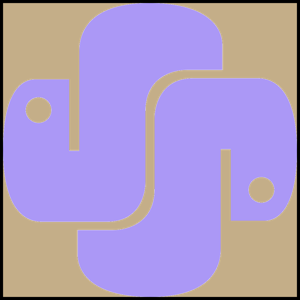

In [827]:
im.sepia()